Prerequsites

In [963]:
!pip install opencv-python numpy matplotlib

Package imports

In [964]:
import cv2
import numpy as np

import matplotlib.pyplot as plt


Q1 - Image Transformation

In [965]:
def intensity_transform(im, breakpoints):
    lut = np.zeros(256, dtype=np.uint8)

    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        for x in range(x1, x2 + 1):
            y = y1 + (y2 - y1) * (x - x1) / (x2 - x1)
            lut[x] = np.clip(y, 0, 255)
            
    return lut

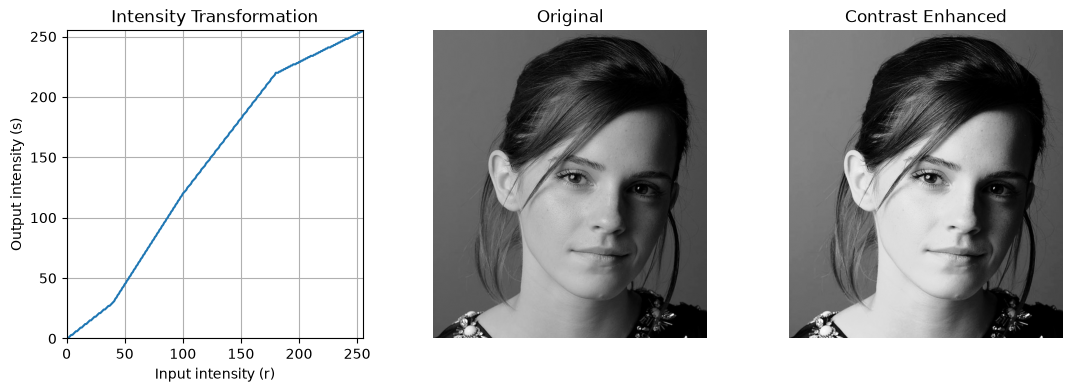

In [966]:
img = cv2.imread("images/q1.jpeg", 0)


# Reasoning behind breakpoints: 
# For a visual enhancement, we should increase the contrast in the mid while keeping the shadows and highlights 
breakpoints = [
    (0, 0),
    (40, 30),
    (100, 120),
    (180, 220),
    (255, 255)
]


lut = intensity_transform(img, breakpoints)

result = cv2.LUT(img, lut)

plt.figure(figsize=(13, 4))

plt.subplot(1, 3, 1)
plt.plot(range(256), lut)
plt.xlabel("Input intensity (r)")
plt.ylabel("Output intensity (s)")
plt.title("Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()

plt.subplot(1, 3, 2)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

#Q2 : Brain Image

Intensity analysis

In [967]:
img = cv2.imread("images/q2.jpeg", 0)

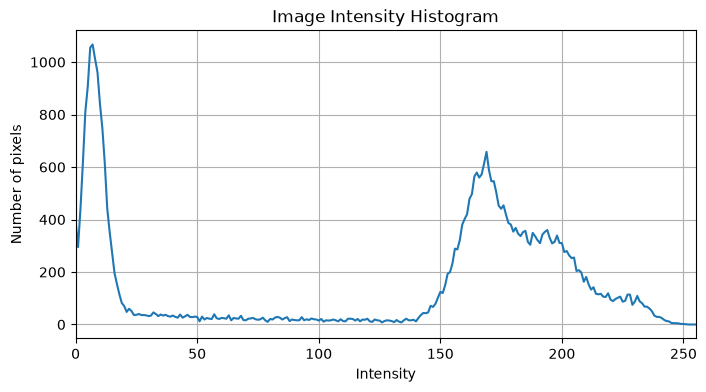

In [968]:
hist = cv2.calcHist([img], [0], None, [256], [0, 256])

plt.figure(figsize=(8, 4))
plt.plot(hist)
plt.xlabel("Intensity")
plt.ylabel("Number of pixels")
plt.title("Image Intensity Histogram")
plt.xlim(0, 255)
plt.grid()
plt.show()

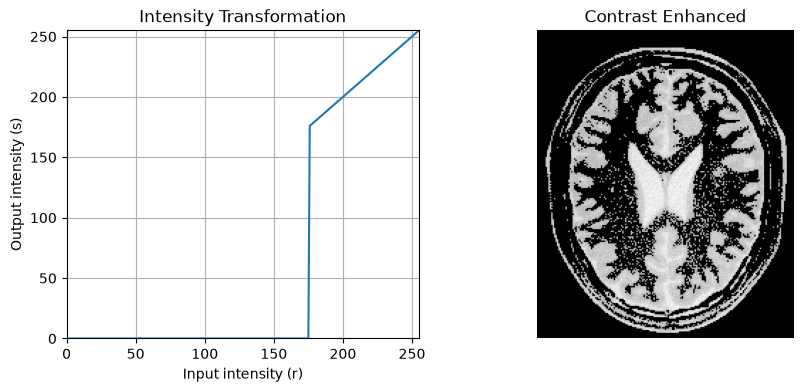

In [969]:

# Reasoning behind breakpoints: 
# 
threshold_l = 175
threshold_h = 220
breakpoints = [
    (0, 0),
    (threshold_l, 0),
    (threshold_l + 1, threshold_l + 1),
    (threshold_h, threshold_h),
    (threshold_h + 1, threshold_h + 1),
    (255, 255)
]

white_lut = intensity_transform(img, breakpoints)

result = cv2.LUT(img, white_lut)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(256), white_lut)
plt.xlabel("Input intensity (r)")
plt.ylabel("Output intensity (s)")
plt.title("Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()

plt.subplot(1, 2, 2)
plt.imshow(result, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

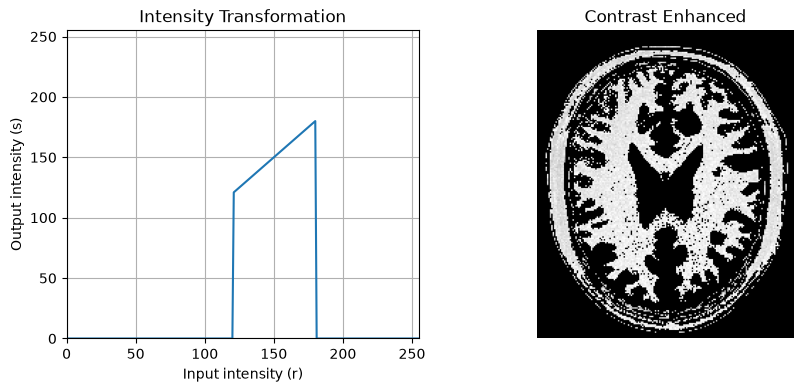

In [970]:
# Reasoning behind breakpoints: 
# 
threshold_l = 120
threshold_h = 180
breakpoints = [
    (0, 0),
    (threshold_l, 0),
    (threshold_l + 1, threshold_l + 1),
    (threshold_h, threshold_h),
    (threshold_h+1, 0),
    (255, 0)
]

white_lut = intensity_transform(img, breakpoints)

result = cv2.LUT(img, white_lut)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(256), white_lut)
plt.xlabel("Input intensity (r)")
plt.ylabel("Output intensity (s)")
plt.title("Intensity Transformation")

plt.xlim(0, 255)
plt.ylim(0, 255)
plt.grid()

plt.subplot(1, 2, 2)
plt.imshow(result, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

#3 : Gamma Correction

In [971]:
def gamma_correct_L(image, gamma=1):
    # BGR -> LAB
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    # Split channels
    L, a, b = cv2.split(lab)

    # Normalize
    L_float = L.astype(np.float32) / 255.0

    # Gamma correction
    L_corrected = np.power(L_float, gamma) * 255.0

    # Convert back to uint8
    L_corrected = np.clip(L_corrected, 0, 255).astype(np.uint8)

    lab_corrected = cv2.merge([L_corrected, a, b])
    result = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2RGB)

    return result

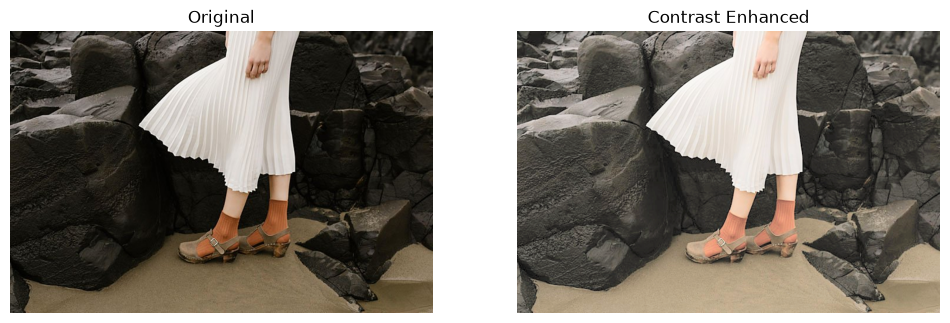

In [972]:
img = cv2.imread("images/q3.jpeg")
corrected = gamma_correct_L(img, gamma=0.5)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

#4. Increasing the vibrance using a intensity transfomation

In [973]:
def intensity_transform_saturation(image, a=0, sigma=70):
    # BGR -> HSV
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    # Split channels
    h, s, v = cv2.split(hsv)

    # Normalize
    s_float = s.astype(np.float32)

    s_corrected = (
        s_float
        + a * 128 * np.exp(
            -((s_float - 128) ** 2) / (2 * sigma ** 2)
        )
    )

    # Convert back to uint8
    s_corrected = np.clip(s_corrected, 0, 255).astype(np.uint8)

    hsv_corrected = cv2.merge([h, s_corrected, v])
    result = cv2.cvtColor(hsv_corrected, cv2.COLOR_HSV2RGB)

    return result

In [974]:
x = np.arange(256, dtype=np.float32)

a = 0.65
y = (
    x
    + a * 128 * np.exp(
        -((x - 128) ** 2) / (2 * 70 ** 2)
    )
)

y = np.clip(y, 0, 255)

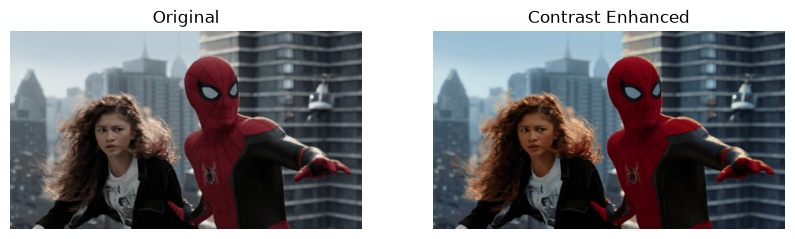

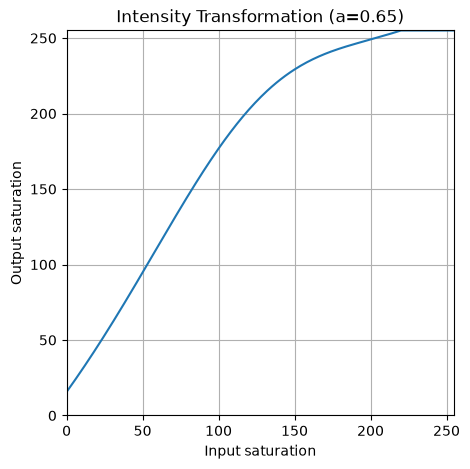

In [975]:
img = cv2.imread("images/q4.jpeg")
corrected = intensity_transform_saturation(img, a=0.65)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

plt.figure(figsize=(5, 5))

plt.plot(x, y)

plt.xlabel("Input saturation")
plt.ylabel("Output saturation")
plt.title(f"Intensity Transformation (a={a})")

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.grid()
plt.show()

# Q5 : Histrogram  Equalization

In [976]:
def histrogram_equalization(img):
    # histrogram calculation usign calcHist function
    hist = cv2.calcHist([img], [0], None, [256], [0, 256])
    cdf = hist.cumsum()

    # Normalize the CDF
    cdf_normalized = cdf / cdf[-1]

    L = 256
    mapping = np.round((L - 1) * cdf_normalized).astype(np.uint8)

    # Apply the mapping to the image
    result = cv2.LUT(img, mapping)

    hist_after = cv2.calcHist([result], [0], None, [256], [0, 256])

    return result, hist, hist_after

[ WARN:0@17114.450] global grfmt_tiff.cpp:123 TIFF_Warning TIFFFetchNormalTag: ASCII value for tag "ImageDescription" does not end in null byte. Forcing it to be null


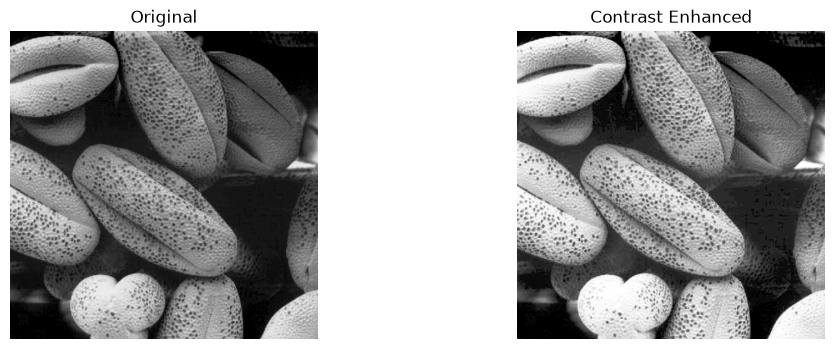

In [977]:
img = cv2.imread("images/shells.tif", 0)
corrected, before_hist, after_hist = histrogram_equalization(img)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(corrected, cmap="gray")
plt.title("Contrast Enhanced")
plt.axis("off")

plt.show()

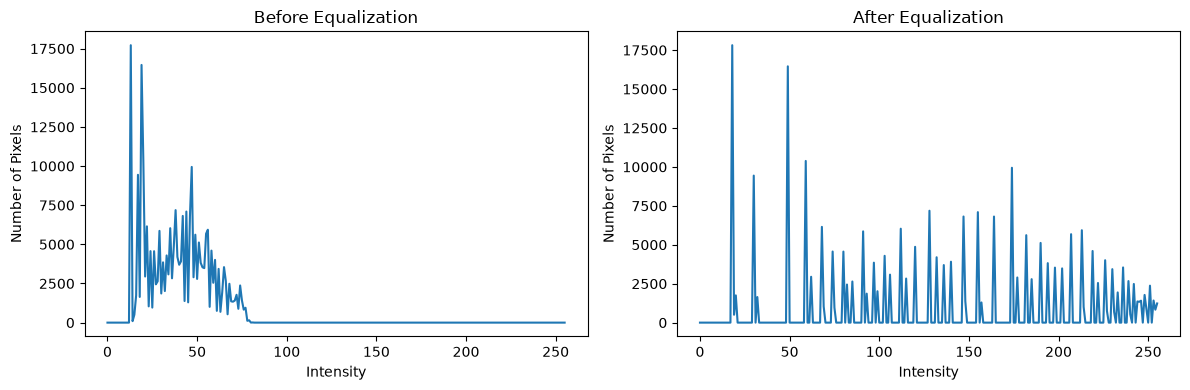

In [978]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(before_hist)
plt.title("Before Equalization")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.subplot(1, 2, 2)
plt.plot(after_hist)
plt.title("After Equalization")
plt.xlabel("Intensity")
plt.ylabel("Number of Pixels")

plt.tight_layout()
plt.show()

# Q5 : Histrogra Equaliztion only for the foreground

In [979]:
def histrogram_equalization_hsv_visualization(img):

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h, s, v = cv2.split(hsv)


    threshold = 15

    _, mask = cv2.threshold(
        s,
        threshold,
        255,
        cv2.THRESH_BINARY
    )

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(h, cmap="gray")
    plt.title("Hue")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(s, cmap="gray")
    plt.title("Saturation")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(v, cmap="gray")
    plt.title("Value")
    plt.axis("off")

    plt.tight_layout()
    plt.show()
    
    plt.imshow(mask, cmap="gray")
    plt.title("Foreground Mask")
    plt.axis("off")
    plt.show()


    return h,s,v,mask

In [980]:
def histrogram_equalization_mask(img, s, mask):
    # histrogram calculation usign calcHist function

    foreground = cv2.bitwise_and(s, s, mask=mask)
    background = cv2.bitwise_and(s, s, mask=cv2.bitwise_not(mask))

    # Compute histogram of foreground saturation
    hist = cv2.calcHist(
        [foreground],
        [0],
        mask,
        [256],
        [0, 256]
    )
    n = np.sum(hist)
    p = hist / n
    cdf = np.cumsum(p)

    # Normalize the CDF
    cdf_normalized = cdf / cdf[-1]

    L = 256
    mapping = np.round((L - 1) * cdf_normalized).astype(np.uint8)

    foreground_equalized = np.zeros_like(s)

    foreground_equalized[mask > 0] = cv2.LUT(foreground[mask > 0], mapping)

    result_s = cv2.add(foreground_equalized, background)
    result_hsv = cv2.merge([h, result_s, v])
    result = cv2.cvtColor(result_hsv, cv2.COLOR_HSV2BGR)

    hist_after = cv2.calcHist([result], [0], None, [256], [0, 256])

    return result, hist, hist_after

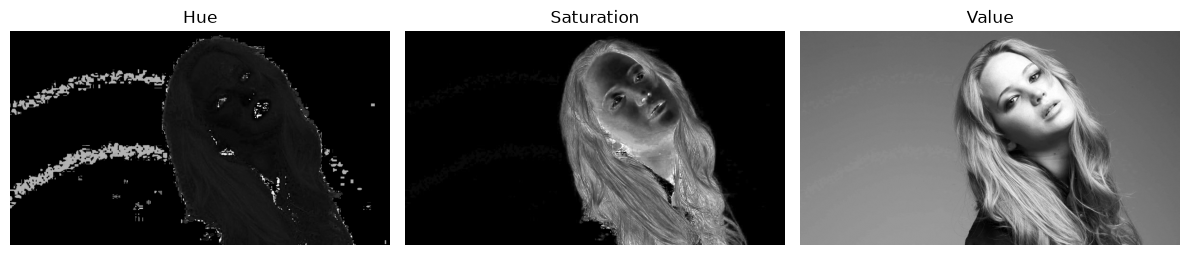

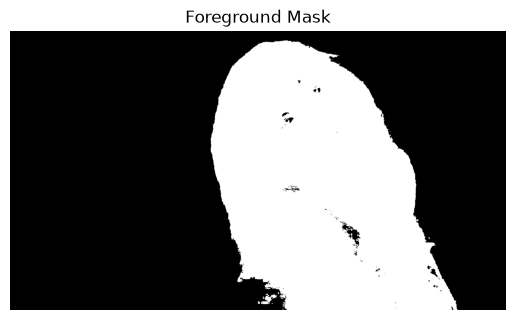

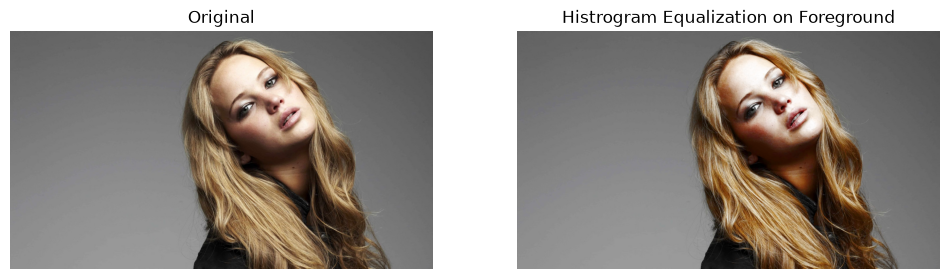

In [981]:
img = cv2.imread("images/q6.jpeg")
h, s, v, mask = histrogram_equalization_hsv_visualization(img)
result, before_hist, after_hist = histrogram_equalization_mask(img, s, mask)
# From our output, to get a mask of foreground we have to go with Saturation channel.

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Histrogram Equalization on Foreground")
plt.axis("off")

plt.show()

# Q7.a : Filtering with the Sobel Operator

In [982]:
def filter_through_filter2D(image):

    sobel_x_kernel = np.array([
        [1, 0, -1],
        [2, 0, -2],
        [1, 0, -1]
    ], dtype=np.float32)

    # cv2.CV_32F is used to specify the desired depth of the output image. It indicates that the output image should have a depth of 32-bit floating-point numbers. This is important because the Sobel filter can produce negative values, and using a floating-point representation allows for a wider range of values, including negative ones, which can be useful for edge detection.
    result = cv2.filter2D(image, cv2.CV_32F, sobel_x_kernel)

    return cv2.convertScaleAbs(result)

In [983]:
def filter_through_from_scratch(image):

    sobel_x_kernel = np.array([
        [1, 0, -1],
        [2, 0, -2],
        [1, 0, -1]
    ], dtype=np.float32)

    x, y = image.shape

    padded_img = np.pad(
        image,
        ((1, 1), (1, 1)),
        mode='constant'
    )

    result = np.zeros_like(image, dtype=np.float32)

    for i in range(x):
        for j in range(y):
            region = padded_img[i:i+3, j:j+3]

            result[i, j] = np.sum(region * sobel_x_kernel)

    return cv2.convertScaleAbs(result)

In [984]:
def filter_through_1D_convo(image):
    sobel_x_kernel = np.array([-1, 0, 1], dtype=np.float32)
    sobel_y_kernel = np.array([1, 2, 1], dtype=np.float32)

    x, y = image.shape


    result_x = np.zeros_like(image, dtype=np.float32)
    result_y = np.zeros_like(image, dtype=np.float32)

    for i in range(x):
        for j in range(1, y - 1):
            result_x[i, j] = np.sum(
                image[i, j-1:j+2] * sobel_x_kernel
            )

    for i in range(1, x - 1):
        for j in range(y):
            result_y[i, j] = np.sum(
                result_x[i-1:i+2, j] * sobel_y_kernel
            )

    return cv2.convertScaleAbs(result_y)

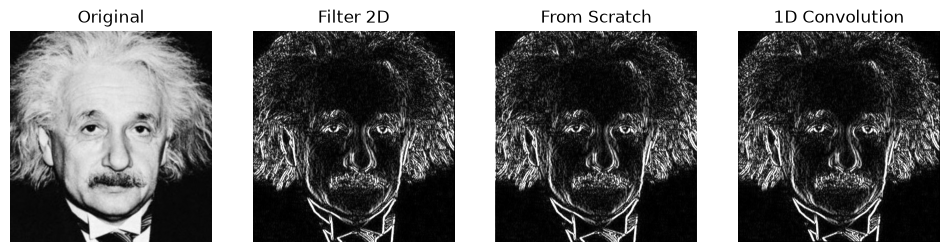

In [985]:
img_ein = cv2.imread("images/q7.jpeg", 0)
result_filter = filter_through_filter2D(img_ein)
result_handwritten = filter_through_from_scratch(img_ein)
result_from_scratch_1D = filter_through_1D_convo(img_ein)
# From our output, to get a mask of foreground we have to go with Saturation channel.

plt.figure(figsize=(12, 8))

plt.subplot(1, 4, 1)
plt.imshow(img_ein, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(result_filter, cmap="gray")
plt.title("Filter 2D")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(result_handwritten, cmap="gray")
plt.title("From Scratch")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(result_from_scratch_1D, cmap="gray")
plt.title("1D Convolution")
plt.axis("off")

plt.show()

# Q9 : Image editing using GrabCut and Blurring

In [986]:
def segment_through_grabcut(image):
    mask = np.zeros(image.shape[:2],np.uint8)
    bgdModel = np.zeros((1,65),np.float64)
    fgdModel = np.zeros((1,65),np.float64)

    rect = (50,140,550,500)  # get the rectangle coordinates relatively by adjusting

    cv2.grabCut(image,mask,rect,bgdModel,fgdModel,10,cv2.GC_INIT_WITH_RECT)
    mask2 = np.where((mask==2)|(mask==0),0,1).astype('uint8')

    foreground = image*mask2[:,:,np.newaxis]
    background = image*(1-mask2[:,:,np.newaxis])

    return mask2, foreground, background

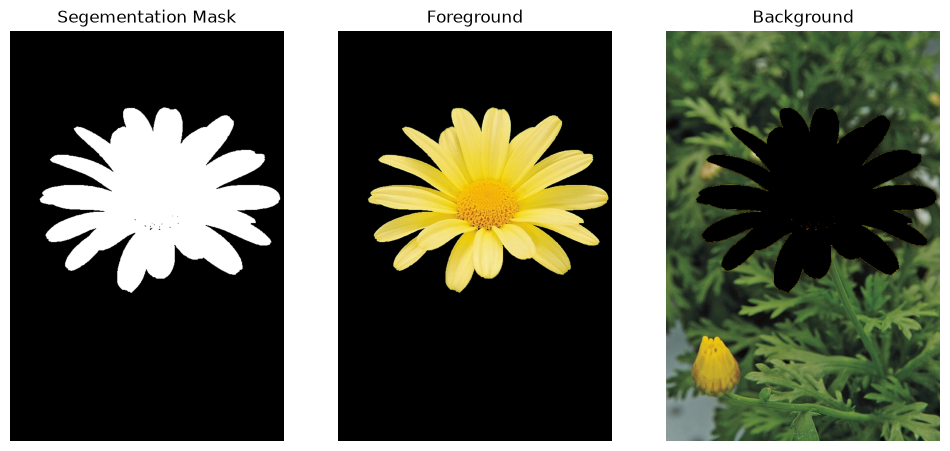

In [987]:
img = cv2.imread("images/q8.jpeg")
mask2, foreground, background = segment_through_grabcut(img)


plt.figure(figsize=(12, 8))

plt.subplot(1, 3, 1)
plt.imshow(mask2, cmap="gray")
plt.title("Segementation Mask")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB))
plt.title("Foreground")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(background, cv2.COLOR_BGR2RGB))
plt.title("Background")
plt.axis("off")

plt.show()

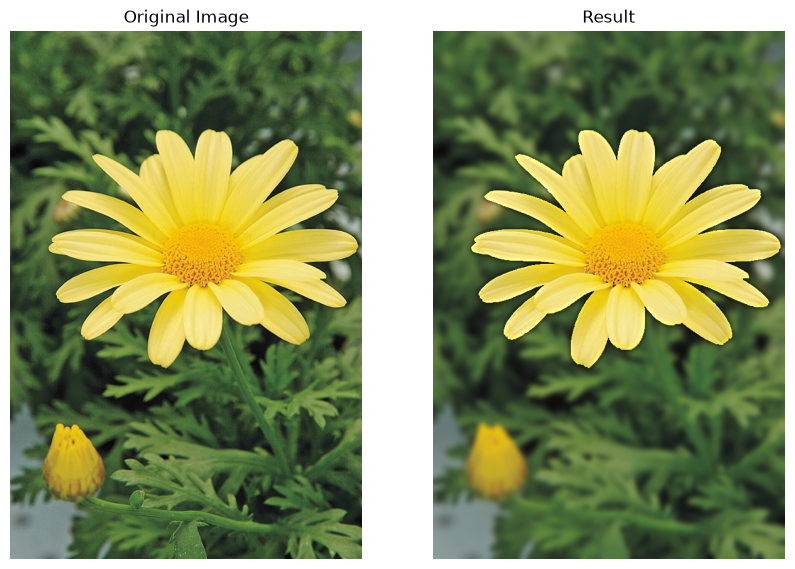

In [988]:
background_blurred = cv2.GaussianBlur(background, (25, 25), 0)

result = cv2.add(foreground, background_blurred)

plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Result")
plt.axis("off")

plt.show()